<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/dl/seq2seq_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📜 seq2seq 첫걸음

> **🎯 이 노트북은 누구를 위한 건가요?**
> - RNN/LSTM 노트북을 마쳤거나, 시퀀스 모델 기본을 들어본 분
> - "**번역**, **요약**, **챗봇** 같은 건 어떻게 만들지?" 가 궁금한 분
> - 입력과 출력 길이가 **다른** task를 어떻게 처리하는지 알고 싶은 분

---

## 📖 오늘의 이야기 한 줄 요약

> **"입력 시퀀스를 받아 → 다른 길이의 출력 시퀀스로 변환하는 모델 — seq2seq."**

비유로 풀자면 — **통역사** 같아요:

```
한국어 문장 (입력) → 통역사가 듣고 머릿속에 정리(요약) → 영어 문장 (출력)
```

이 통역사가 두 명의 LSTM 으로 이루어져 있다고 보면 됩니다:
- 🎧 **인코더** (Encoder) — 입력을 끝까지 듣고 요약
- 🗣️ **디코더** (Decoder) — 그 요약을 받아 출력 시퀀스 생성

## 🛠️ 준비물

| 항목 | 내용 |
|---|---|
| 환경 | Google Colab (무료) |
| 가속기 | T4 GPU 권장 (학습 시간 단축) |
| 시간 | 약 60~80분 (학습 ~3분 포함) |
| 사전 지식 | LSTM 노트북 또는 LSTM 기본 |
| 실전 task | **한글 숫자 → 아라비아 숫자** 변환 (예: "삼백오십칠" → "357") |

## 🗺️ 학습 로드맵

```
1️⃣ 왜 seq2seq? — 입력/출력 길이가 다른 task
2️⃣ 통역사 비유 + Encoder-Decoder 구조
3️⃣ Context Vector — 정보의 압축 병목
4️⃣ Teacher Forcing — 학습 시 트릭
5️⃣ 환경 + 데이터 (한글 숫자 ↔ 아라비아 숫자)
6️⃣ 🎯 미션 1: Encoder 구현 + Decoder 한 step ✏️
7️⃣ 학습 (Teacher Forcing)
8️⃣ 추론 (Autoregressive — 자기 출력을 다시 입력)
9️⃣ 🎯 미션 2: Teacher Forcing 효과 비교 ✏️
🔟 도전 과제 + 정리
```

> **💡 학습 팁**: seq2seq의 진짜 핵심은 **"학습 모드와 추론 모드가 다르다"** 는 것!
> Teacher Forcing이 그 비밀입니다. 미션 1에서 직접 다뤄봅시다.


---
# 1️⃣ seq2seq의 동기 — 길이가 다른 변환

## 1.1 RNN/LSTM의 한계 — 길이 문제

지금까지 RNN/LSTM은 **"앞 N개 → 다음 1개"** 같은 task만 다뤘어요:
```
입력 길이 = 20  → 출력 길이 = 1     (예측)
입력 길이 = 100 → 출력 길이 = 1     (분류)
```

근데 실제 문제는 입력/출력 길이가 **자유롭게** 달라요:
| Task | 입력 | 출력 |
|---|---|---|
| **번역** | "I love you" (3 단어) | "나는 너를 사랑해" (4 단어) |
| **요약** | 긴 기사 (1000 단어) | 짧은 요약 (50 단어) |
| **챗봇** | "오늘 날씨?" (2 단어) | "흐리고 비 예보입니다" (3 단어) |
| **OCR** | 이미지 (n 픽셀) | 텍스트 (m 글자) |
| **음성→텍스트** | 음파 (k 샘플) | 문장 (j 단어) |

## 1.2 [비유로 이해] 통역사의 일하는 방식 📜

UN 회의장의 한국어→영어 통역사를 생각해봅시다:

```
1단계: 🎧 한국어 문장을 끝까지 듣는다
       머릿속에 핵심 의미를 압축 (= context vector)

2단계: 🗣️ 그 압축된 의미를 바탕으로 영어 문장을 한 단어씩 만들어 발화
       이전에 자기가 말한 단어를 떠올리며 다음 단어 결정
```

이게 정확히 seq2seq의 동작 방식이에요:

| 통역사 단계 | 모델 컴포넌트 | 비유 |
|---|---|---|
| 듣기 | **Encoder** (LSTM) | 입력 시퀀스를 끝까지 처리 |
| 핵심 압축 | **Context vector** | Encoder의 마지막 hidden state |
| 발화 | **Decoder** (LSTM) | Context로 시작해 한 토큰씩 출력 |

## 1.3 [그림으로 보기] 전체 구조


In [1]:
!apt-get install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null

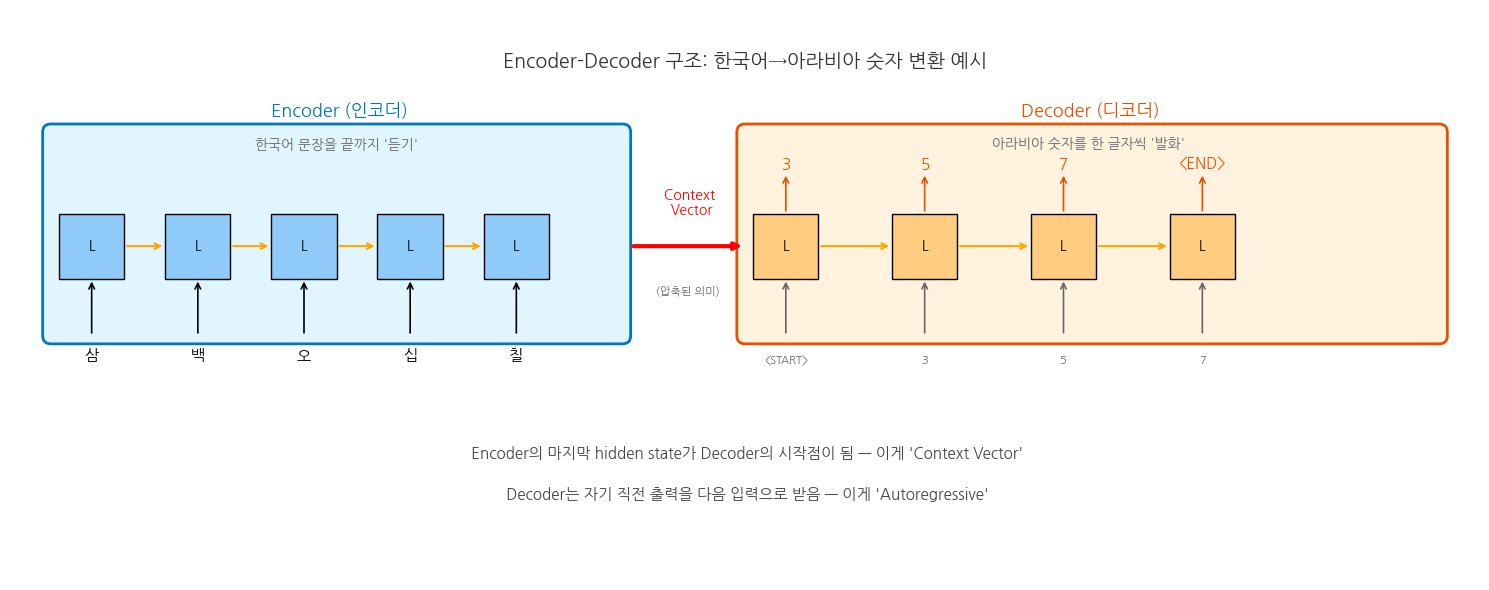


✅ 핵심 정리:
  - Encoder: 입력을 끝까지 처리 → 마지막 hidden state = '요약'
  - Context vector: 그 요약 자체 (Decoder의 초기 상태로 전달)
  - Decoder: <START> 토큰부터 시작해 한 토큰씩 출력, 자기 출력을 다음 입력으로


In [2]:
# 🖼️ seq2seq 구조 — Encoder-Decoder 시각화

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.font_manager as fm
import numpy as np
import os

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(15, 6))
ax.set_xlim(0, 18); ax.set_ylim(0, 7)
ax.axis("off")

# ── Encoder 영역 ──
ax.add_patch(patches.FancyBboxPatch((0.5, 3), 7, 2.5, boxstyle="round,pad=0.1",
    facecolor="#E1F5FE", edgecolor="#0277BD", lw=2))
ax.text(4, 5.7, " Encoder (인코더)", ha="center", fontsize=13, fontweight="bold",
        color="#0277BD")
ax.text(4, 5.3, "한국어 문장을 끝까지 '듣기'", ha="center", fontsize=10, color="#666")

# Encoder LSTM cells
encoder_inputs = ["삼", "백", "오", "십", "칠"]
for i, inp in enumerate(encoder_inputs):
    x = 1.0 + i * 1.3
    # LSTM cell
    ax.add_patch(patches.Rectangle((x - 0.4, 3.7), 0.8, 0.8,
        facecolor="#90CAF9", edgecolor="black", lw=1))
    ax.text(x, 4.1, "L", ha="center", va="center", fontsize=10, fontweight="bold")
    # Input below
    ax.annotate("", xy=(x, 3.7), xytext=(x, 3.0),
                arrowprops=dict(arrowstyle="->", lw=1.2))
    ax.text(x, 2.7, inp, ha="center", fontsize=11, fontweight="bold")
    # Horizontal hidden state
    if i < len(encoder_inputs) - 1:
        ax.annotate("", xy=(x + 0.9, 4.1), xytext=(x + 0.4, 4.1),
                    arrowprops=dict(arrowstyle="->", lw=1.5, color="#FFA500"))

# ── Context vector (가운데 화살표) ──
ax.annotate("", xy=(9.0, 4.1), xytext=(7.6, 4.1),
            arrowprops=dict(arrowstyle="->", lw=3, color="red"))
ax.text(8.3, 4.5, " Context\n  Vector", ha="center", fontsize=10,
        color="red", fontweight="bold")
ax.text(8.3, 3.5, "(압축된 의미)", ha="center", fontsize=8, color="#666", style="italic")

# ── Decoder 영역 ──
ax.add_patch(patches.FancyBboxPatch((9.0, 3), 8.5, 2.5, boxstyle="round,pad=0.1",
    facecolor="#FFF3E0", edgecolor="#E65100", lw=2))
ax.text(13.2, 5.7, " Decoder (디코더)", ha="center", fontsize=13, fontweight="bold",
        color="#E65100")
ax.text(13.2, 5.3, "아라비아 숫자를 한 글자씩 '발화'", ha="center", fontsize=10, color="#666")

# Decoder LSTM cells (3 outputs: 3, 5, 7)
decoder_outputs = ["3", "5", "7", "<END>"]
for i, out in enumerate(decoder_outputs):
    x = 9.5 + i * 1.7
    ax.add_patch(patches.Rectangle((x - 0.4, 3.7), 0.8, 0.8,
        facecolor="#FFCC80", edgecolor="black", lw=1))
    ax.text(x, 4.1, "L", ha="center", va="center", fontsize=10, fontweight="bold")
    # Output above
    ax.annotate("", xy=(x, 5.0), xytext=(x, 4.5),
                arrowprops=dict(arrowstyle="->", lw=1.2, color="#E65100"))
    ax.text(x, 5.05, out, ha="center", fontsize=11, color="#E65100", fontweight="bold")
    # Horizontal
    if i < len(decoder_outputs) - 1:
        ax.annotate("", xy=(x + 1.3, 4.1), xytext=(x + 0.4, 4.1),
                    arrowprops=dict(arrowstyle="->", lw=1.5, color="#FFA500"))
    # Decoder input below: previous output (or <START>)
    prev = "<START>" if i == 0 else decoder_outputs[i-1]
    ax.annotate("", xy=(x, 3.7), xytext=(x, 3.0),
                arrowprops=dict(arrowstyle="->", lw=1.2, color="#666"))
    ax.text(x, 2.65, prev, ha="center", fontsize=8, color="#666")

ax.text(9, 6.3, "Encoder-Decoder 구조: 한국어→아라비아 숫자 변환 예시",
        fontsize=14, fontweight="bold", color="#333", ha="center")
ax.text(9, 1.5, " Encoder의 마지막 hidden state가 Decoder의 시작점이 됨 — 이게 'Context Vector'",
        ha="center", fontsize=11, color="#444")
ax.text(9, 1, " Decoder는 자기 직전 출력을 다음 입력으로 받음 — 이게 'Autoregressive'",
        ha="center", fontsize=11, color="#444")

plt.tight_layout(); plt.show()

print("\n✅ 핵심 정리:")
print("  - Encoder: 입력을 끝까지 처리 → 마지막 hidden state = '요약'")
print("  - Context vector: 그 요약 자체 (Decoder의 초기 상태로 전달)")
print("  - Decoder: <START> 토큰부터 시작해 한 토큰씩 출력, 자기 출력을 다음 입력으로")

---
# 2️⃣ Teacher Forcing — 학습 시 트릭

## 2.1 [문제] 학습이 너무 어려움

Decoder는 자기 직전 출력을 다음 입력으로 써요. 학습 초기엔 출력이 엉터리니까:
```
시각 1: <START> → 'X' (틀림)
시각 2: 'X' (틀린 입력) → 'Y' (또 틀림)
시각 3: 'Y' → 'Z' (계속 틀림)
...
```
**오류가 누적되어 학습이 매우 느려져요.**

## 2.2 [해결] Teacher Forcing — "정답을 슬쩍 보여주기"

선생님이 시험 풀 때 **정답을 살짝 보여주며** 가르치는 거예요.

```
학습 시:
시각 1: <START> → 모델 출력 'X', 정답은 '3' → loss 계산
       다음 입력은? → 모델 출력 X 가 아니라, 정답 '3' 사용!
시각 2: '3' (정답 입력) → 모델 출력 'W', 정답 '5' → loss
       다음 입력은? → 정답 '5' 사용!
...
```

**모델이 항상 올바른 history 위에서 다음을 예측하게** 만드는 거예요.
이 덕분에 학습이 안정적이고 빨라집니다.

| 모드 | Decoder 입력 | 사용 시점 |
|---|---|---|
| **Teacher Forcing** | **정답** 시퀀스 (shifted) | **학습 시** |
| **Autoregressive** | 모델의 **이전 출력** | **추론 시 (실전)** |

> ⚠️ **함정**: Teacher Forcing으로만 학습하면, 추론 시 한 번 틀리면 그 다음 다 망가지는
> "exposure bias" 가 생길 수 있어요. 실무에선 둘을 섞기도 합니다 (scheduled sampling).

## 2.3 [그림] 학습 vs 추론 모드 차이

```
[학습 모드 - Teacher Forcing]
정답: 3 5 7 <END>
입력: <START> 3 5 7    ← 정답을 한 칸 밀어서 입력
예측: 3?     5? 7? <END>?

[추론 모드 - Autoregressive]
입력: <START> → 모델 → '3'
입력: '3'    → 모델 → '5'
입력: '5'    → 모델 → '7'
입력: '7'    → 모델 → '<END>'  ← 종료!
```

이걸 코드로 미션 1, 2에서 다뤄봅니다.


---
# 3️⃣ 환경 + 데이터 (한글 숫자 ↔ 아라비아 숫자)

오늘의 task: **"삼백오십칠" → "357"** 같은 변환을 학습.

> 💡 **왜 이 task?**
> - 입력/출력 길이가 다름 (seq2seq의 핵심)
> - 데이터를 무한히 만들 수 있음 (수동 라벨링 X)
> - 결과가 명확 — 맞는지 한눈에 확인


In [3]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os, sys, random

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

torch.manual_seed(42); np.random.seed(42); random.seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} / 디바이스 {device}")

PyTorch 2.10.0+cu128 / 디바이스 cuda


## 3.1 한글 숫자 변환 함수 만들기

1~9999 사이 숫자를 한글로 표현하는 함수. 이걸로 (한글, 아라비아) 쌍 무한히 생성.


In [4]:
def num_to_korean(n):
    """0~9999 → 한글 표기 (예: 357 → '삼백오십칠')"""
    digits_kor = ['', '일', '이', '삼', '사', '오', '육', '칠', '팔', '구']
    if n == 0:
        return '영'

    parts = []
    # 천의 자리
    if n >= 1000:
        d = n // 1000
        parts.append((digits_kor[d] if d > 1 else '') + '천')
        n %= 1000
    # 백의 자리
    if n >= 100:
        d = n // 100
        parts.append((digits_kor[d] if d > 1 else '') + '백')
        n %= 100
    # 십의 자리
    if n >= 10:
        d = n // 10
        parts.append((digits_kor[d] if d > 1 else '') + '십')
        n %= 10
    # 일의 자리
    if n > 0:
        parts.append(digits_kor[n])

    return ''.join(parts)


# 테스트
for n in [3, 47, 100, 357, 1024, 9999]:
    print(f"  {n:>4} → {num_to_korean(n)}")

# 데이터 생성: 1~9999 중 5000개 랜덤
N_DATA = 5000
all_numbers = random.sample(range(1, 10000), N_DATA)

pairs = [(num_to_korean(n), str(n)) for n in all_numbers]
print(f"\n📊 생성된 데이터: {len(pairs)} 쌍")
print(f"예시: {pairs[:5]}")

     3 → 삼
    47 → 사십칠
   100 → 백
   357 → 삼백오십칠
  1024 → 천이십사
  9999 → 구천구백구십구

📊 생성된 데이터: 5000 쌍
예시: [('천팔백이십오', '1825'), ('사백십', '410'), ('사천오백칠', '4507'), ('사천십삼', '4013'), ('삼천육백오십팔', '3658')]


## 3.2 어휘 사전 만들기 (글자 → 숫자 ID 변환)

신경망은 텍스트를 직접 못 다뤄요. **각 글자를 정수 ID로 변환** 해야 합니다.


In [5]:
PAD, SOS, EOS = '<PAD>', '<SOS>', '<EOS>'    # 특수 토큰

# 입력 어휘 (한글) — 모든 가능한 한글 자모를 모음
src_chars = set()
for kor, _ in pairs:
    src_chars.update(kor)
src_vocab = [PAD] + sorted(src_chars)
src_char_to_id = {c: i for i, c in enumerate(src_vocab)}
src_id_to_char = {i: c for c, i in src_char_to_id.items()}

# 출력 어휘 (아라비아 숫자 + 특수 토큰)
tgt_chars = set()
for _, num in pairs:
    tgt_chars.update(num)
tgt_vocab = [PAD, SOS, EOS] + sorted(tgt_chars)
tgt_char_to_id = {c: i for i, c in enumerate(tgt_vocab)}
tgt_id_to_char = {i: c for c, i in tgt_char_to_id.items()}

print(f"입력(한글) 어휘 수: {len(src_vocab)}")
print(f"  글자: {src_vocab}")
print(f"\n출력(숫자) 어휘 수: {len(tgt_vocab)}")
print(f"  글자: {tgt_vocab}")


def encode_src(text, max_len):
    """한글 → ID 리스트, 패딩"""
    ids = [src_char_to_id[c] for c in text]
    ids += [src_char_to_id[PAD]] * (max_len - len(ids))
    return ids


def encode_tgt(text, max_len):
    """숫자 → SOS + ID 리스트 + EOS, 패딩"""
    ids = [tgt_char_to_id[SOS]] + [tgt_char_to_id[c] for c in text] + [tgt_char_to_id[EOS]]
    ids += [tgt_char_to_id[PAD]] * (max_len - len(ids))
    return ids


# 인코딩 테스트
print(f"\n예시: '{pairs[0][0]}' → {encode_src(pairs[0][0], 8)}")
print(f"예시: '{pairs[0][1]}' → {encode_tgt(pairs[0][1], 6)}")

입력(한글) 어휘 수: 13
  글자: ['<PAD>', '구', '백', '사', '삼', '십', '오', '육', '이', '일', '천', '칠', '팔']

출력(숫자) 어휘 수: 13
  글자: ['<PAD>', '<SOS>', '<EOS>', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

예시: '천팔백이십오' → [10, 12, 2, 8, 5, 6, 0, 0]
예시: '1825' → [1, 4, 11, 5, 8, 2]


## 3.3 텐서로 변환 + train/test 분리


In [6]:
# 최대 길이 정하기
SRC_MAX_LEN = max(len(k) for k, _ in pairs)
TGT_MAX_LEN = max(len(n) for _, n in pairs) + 2  # +2 for SOS, EOS
print(f"SRC 최대 길이: {SRC_MAX_LEN}")
print(f"TGT 최대 길이: {TGT_MAX_LEN}  (+SOS +EOS 포함)")

# 텐서로 변환
src_data = torch.LongTensor([encode_src(k, SRC_MAX_LEN) for k, _ in pairs])
tgt_data = torch.LongTensor([encode_tgt(n, TGT_MAX_LEN) for _, n in pairs])

print(f"\nsrc_data.shape = {src_data.shape}  (샘플 수, 입력 길이)")
print(f"tgt_data.shape = {tgt_data.shape}  (샘플 수, 출력 길이)")

# 80% train / 20% test 분리
split = int(0.8 * len(pairs))
src_train, src_test = src_data[:split].to(device), src_data[split:].to(device)
tgt_train, tgt_test = tgt_data[:split].to(device), tgt_data[split:].to(device)
pairs_test = pairs[split:]

print(f"\nTrain: {src_train.shape[0]} 샘플, Test: {src_test.shape[0]} 샘플")

SRC 최대 길이: 7
TGT 최대 길이: 6  (+SOS +EOS 포함)

src_data.shape = torch.Size([5000, 7])  (샘플 수, 입력 길이)
tgt_data.shape = torch.Size([5000, 6])  (샘플 수, 출력 길이)

Train: 4000 샘플, Test: 1000 샘플


---
# 4️⃣ 🎯 미션 1: Encoder forward + Decoder 한 step ✏️

이 미션이 seq2seq의 진짜 핵심이에요. **Encoder의 출력 → Decoder의 입력** 흐름을 직접 만들어봅시다.

## 4.1 Encoder는 어렵지 않음 — 그냥 LSTM

Encoder는 입력 시퀀스를 끝까지 LSTM에 통과시키고 **마지막 hidden state(+cell state)** 만 반환합니다.

```python
output, (h, c) = self.lstm(embedded_input)
return h, c    # ← 이게 Decoder의 시작점!
```

## 4.2 Decoder도 LSTM이지만, **한 step씩** 호출

Decoder는 보통 LSTM 호출 시 **시퀀스 전체** 가 아니라 **한 토큰씩** 호출합니다 (autoregressive 추론 때문).

```python
output, (h, c) = self.lstm(one_token, (prev_h, prev_c))  # h는 누적
logits = self.fc(output)                                 # 다음 토큰 확률
```

> **⏰ 7분 도전!** 빈칸 5개. Embedding 레이어와 LSTM을 연결해야 합니다.


In [7]:
# 🎯 미션 1: Encoder + Decoder 빈칸 채우기

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        # Embedding: ID → 벡터 (one-hot보다 효율적)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

    def forward(self, src):
        """
        src: (batch, src_len)  — 입력 한글 시퀀스 (ID)
        반환: (h_n, c_n) — 마지막 hidden/cell state (Decoder의 시작점)
        """
        # ── Step 1: 임베딩 ──
        # 💡 힌트: ID 시퀀스를 벡터로 변환
        embedded = self.embedding(src)            # ✏️ embedding

        # ── Step 2: LSTM 통과 ──
        # 💡 힌트: 시퀀스 전체 입력. 출력은 (output, (h_n, c_n))
        output, (h_n, c_n) = self.lstm(embedded)    # ✏️ lstm

        # ── Step 3: 마지막 상태만 반환 ──
        # 💡 힌트: h_n과 c_n을 튜플로 반환 (= context vector)
        return h_n, c_n                      # ✏️ h_n, c_n


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        # 출력 → 어휘 확률
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_token, h_prev, c_prev):
        """
        입력: 한 토큰만! (autoregressive 처리용)
        input_token: (batch, 1)        — 한 시각 입력
        h_prev, c_prev: 직전 LSTM 상태
        반환: logits (batch, vocab_size), 갱신된 (h, c)
        """
        # ── Step 4: 한 토큰 임베딩 ──
        embedded = self.embedding(input_token)            # (batch, 1, embed_dim)

        # ── Step 5: LSTM 한 step ──
        # 💡 힌트: 직전 상태 (h_prev, c_prev) 를 넘김
        output, (h, c) = self.lstm(embedded, (h_prev, c_prev))   # ✏️ h_prev, c_prev

        # ── Step 6: 어휘 확률 logits ──
        # output: (batch, 1, hidden) → squeeze해서 (batch, hidden)
        logits = self.fc(output.squeeze(1))               # (batch, vocab_size)

        return logits, h, c


print("✏️ 빈칸 다 채우셨나요? 다음 검증 셀로 가보세요.")

✏️ 빈칸 다 채우셨나요? 다음 검증 셀로 가보세요.


<details>
<summary>🔑 정답</summary>

```python
embedded = self.embedding(src)
output, (h_n, c_n) = self.lstm(embedded)
return h_n, c_n
output, (h, c) = self.lstm(embedded, (h_prev, c_prev))
```

**핵심 패턴**:
- Embedding: 정수 ID → 학습 가능한 dense vector
- Encoder: 시퀀스 전체 처리 → 마지막 상태만 반환
- Decoder: 한 토큰 + 직전 상태 → 다음 토큰 확률 + 갱신된 상태

</details>

## 4.3 미션 1 검증 — Encoder/Decoder 동작 확인


In [8]:
# 🧪 미션 1 검증

EMBED_DIM = 32
HIDDEN_DIM = 128

encoder = Encoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM).to(device)
decoder = Decoder(len(tgt_vocab), EMBED_DIM, HIDDEN_DIM).to(device)

# 작은 배치로 테스트
test_src = src_train[:4]                       # (4, src_len)
print(f"Encoder 입력 shape: {test_src.shape}")

h, c = encoder(test_src)
print(f"Encoder 출력 h.shape: {h.shape}, c.shape: {c.shape}")
print(f"  → (1 layer, batch=4, hidden={HIDDEN_DIM})")

# Decoder 한 step
sos_token = torch.LongTensor([[tgt_char_to_id[SOS]]] * 4).to(device)  # (4, 1)
print(f"\nDecoder 입력 (SOS) shape: {sos_token.shape}")

logits, h, c = decoder(sos_token, h, c)
print(f"Decoder 출력 logits shape: {logits.shape}")
print(f"  → (batch=4, vocab_size={len(tgt_vocab)})")

# 검증
assert h.shape == (1, 4, HIDDEN_DIM)
assert logits.shape == (4, len(tgt_vocab))
print(f"\n🎉 미션 1 성공!")
print(f"   Encoder/Decoder 모두 형식 OK. 이제 학습을 시작합니다.")

Encoder 입력 shape: torch.Size([4, 7])
Encoder 출력 h.shape: torch.Size([1, 4, 128]), c.shape: torch.Size([1, 4, 128])
  → (1 layer, batch=4, hidden=128)

Decoder 입력 (SOS) shape: torch.Size([4, 1])
Decoder 출력 logits shape: torch.Size([4, 13])
  → (batch=4, vocab_size=13)

🎉 미션 1 성공!
   Encoder/Decoder 모두 형식 OK. 이제 학습을 시작합니다.


## 4.4 Seq2Seq 클래스 — 학습용 forward (Teacher Forcing) 결합

이제 Encoder와 Decoder를 묶고, **Teacher Forcing** 으로 학습 시 forward를 정의합니다.


In [9]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, tgt_vocab_size):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.tgt_vocab_size = tgt_vocab_size

    def forward(self, src, tgt, teacher_forcing_ratio=1.0):
        """
        학습용 forward — Teacher Forcing 사용.

        src: (batch, src_len)
        tgt: (batch, tgt_len)  — SOS로 시작하는 정답 시퀀스
        teacher_forcing_ratio: 0~1, 정답을 입력으로 쓸 확률 (1=항상 정답 사용)

        반환: outputs (batch, tgt_len, vocab) — 각 시각 logits
        """
        batch, tgt_len = tgt.shape
        outputs = torch.zeros(batch, tgt_len, self.tgt_vocab_size, device=src.device)

        # Encoder
        h, c = self.encoder(src)

        # 첫 입력은 SOS
        input_token = tgt[:, 0:1]   # (batch, 1)

        # 한 step씩 Decoder 호출
        for t in range(1, tgt_len):
            logits, h, c = self.decoder(input_token, h, c)
            outputs[:, t, :] = logits

            # Teacher Forcing 결정
            if random.random() < teacher_forcing_ratio:
                input_token = tgt[:, t:t+1]               # 정답 사용
            else:
                input_token = logits.argmax(-1, keepdim=True)   # 모델 출력 사용

        return outputs

    @torch.no_grad()
    def predict(self, src, max_len=10, sos_id=None, eos_id=None):
        """
        추론용 — 자기 출력을 다음 입력으로 (autoregressive).

        반환: (batch, max_len) 예측 토큰 시퀀스
        """
        self.eval()
        h, c = self.encoder(src)
        batch = src.shape[0]
        input_token = torch.full((batch, 1), sos_id, dtype=torch.long, device=src.device)

        results = []
        for _ in range(max_len):
            logits, h, c = self.decoder(input_token, h, c)
            input_token = logits.argmax(-1, keepdim=True)
            results.append(input_token)
            # batch 전체가 EOS면 종료
            if (input_token == eos_id).all():
                break

        return torch.cat(results, dim=1)


# 모델 생성
model = Seq2Seq(encoder, decoder, len(tgt_vocab)).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Seq2Seq 파라미터 수: {n_params:,}")

Seq2Seq 파라미터 수: 168,397


## 4.5 학습 (Teacher Forcing 100%)


In [10]:
def train_seq2seq(model, src_train, tgt_train, src_test, tgt_test,
                  n_epochs=20, batch_size=64, lr=0.005, tf_ratio=1.0):
    """seq2seq 학습 함수."""
    criterion = nn.CrossEntropyLoss(ignore_index=tgt_char_to_id[PAD])
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, test_losses = [], []
    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(len(src_train))
        total = 0.0

        for i in range(0, len(src_train), batch_size):
            idx = perm[i:i+batch_size]
            src_b, tgt_b = src_train[idx], tgt_train[idx]

            optimizer.zero_grad()
            outputs = model(src_b, tgt_b, teacher_forcing_ratio=tf_ratio)

            # outputs[:, 1:] (SOS 다음부터) vs tgt[:, 1:] (정답)
            loss = criterion(
                outputs[:, 1:].reshape(-1, len(tgt_vocab)),
                tgt_b[:, 1:].reshape(-1)
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item() * len(idx)

        train_losses.append(total / len(src_train))

        # Test loss
        model.eval()
        with torch.no_grad():
            outputs = model(src_test, tgt_test, teacher_forcing_ratio=1.0)
            test_loss = criterion(
                outputs[:, 1:].reshape(-1, len(tgt_vocab)),
                tgt_test[:, 1:].reshape(-1)
            ).item()
            test_losses.append(test_loss)

        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1:>2}/{n_epochs}  train={train_losses[-1]:.4f}  "
                  f"test={test_losses[-1]:.4f}")

    return train_losses, test_losses


print("⚙️ seq2seq 학습 시작 (Teacher Forcing 100%)")
print("   ~3분 정도 걸려요. 끝나면 추론 결과 확인.\n")
train_losses, test_losses = train_seq2seq(model, src_train, tgt_train, src_test, tgt_test)
print("\n✅ 학습 완료!")

⚙️ seq2seq 학습 시작 (Teacher Forcing 100%)
   ~3분 정도 걸려요. 끝나면 추론 결과 확인.

Epoch  2/20  train=0.2520  test=0.1069
Epoch  4/20  train=0.0160  test=0.0136
Epoch  6/20  train=0.0037  test=0.0049
Epoch  8/20  train=0.0193  test=0.0467
Epoch 10/20  train=0.0037  test=0.0023
Epoch 12/20  train=0.0009  test=0.0013
Epoch 14/20  train=0.0006  test=0.0010
Epoch 16/20  train=0.0005  test=0.0008
Epoch 18/20  train=0.0004  test=0.0007
Epoch 20/20  train=0.0003  test=0.0006

✅ 학습 완료!


## 4.6 학습 곡선 시각화


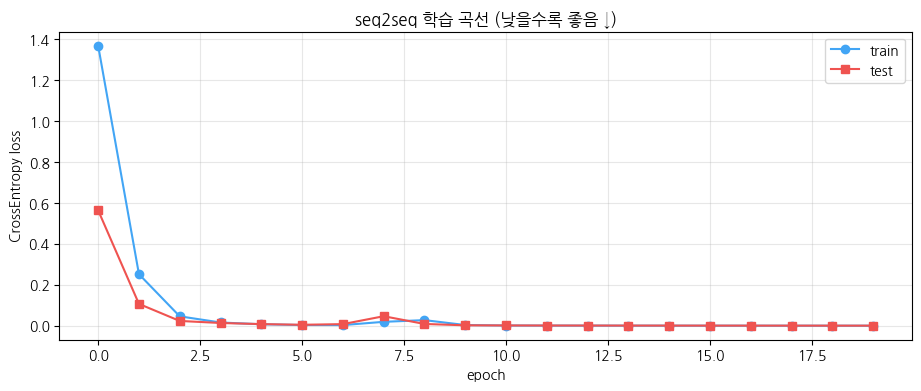

📊 최종 train loss: 0.0003
📊 최종 test  loss: 0.0006


In [11]:
plt.figure(figsize=(11, 4))
plt.plot(train_losses, "o-", label="train", color="#42a5f5")
plt.plot(test_losses, "s-", label="test", color="#ef5350")
plt.xlabel("epoch"); plt.ylabel("CrossEntropy loss")
plt.title("seq2seq 학습 곡선 (낮을수록 좋음 ↓)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f"📊 최종 train loss: {train_losses[-1]:.4f}")
print(f"📊 최종 test  loss: {test_losses[-1]:.4f}")

## 4.7 ⭐ 추론 결과 — 진짜로 변환되나?

학습 끝났으니 test 샘플 몇 개에 직접 변환을 돌려봅시다. **autoregressive 모드** 로!


In [12]:
def decode_prediction(pred_ids):
    """예측 ID 시퀀스를 문자열로 — EOS 만나면 종료"""
    chars = []
    for tid in pred_ids:
        c = tgt_id_to_char[tid.item()]
        if c == EOS:
            break
        if c not in (PAD, SOS):
            chars.append(c)
    return ''.join(chars)


# Test set 첫 15개 샘플 추론
print(f"{'한글 입력':<12}{'정답':<8}{'모델 예측':<10}{'결과'}")
print("-" * 50)
n_correct = 0
for i in range(15):
    src_one = src_test[i:i+1]
    pred_ids = model.predict(src_one,
                              max_len=TGT_MAX_LEN,
                              sos_id=tgt_char_to_id[SOS],
                              eos_id=tgt_char_to_id[EOS])

    pred_str = decode_prediction(pred_ids[0])
    kor_input, true_num = pairs_test[i]
    correct = pred_str == true_num
    if correct:
        n_correct += 1
    mark = "✅" if correct else "❌"
    print(f"  {kor_input:<10}{true_num:<8}{pred_str:<10}{mark}")

print("-" * 50)

# 전체 test 정확도
print("\n⏳ 전체 test set 정확도 측정 중...")
n_total_correct = 0
for i in range(0, len(src_test), 64):
    batch = src_test[i:i+64]
    preds = model.predict(batch, max_len=TGT_MAX_LEN,
                          sos_id=tgt_char_to_id[SOS],
                          eos_id=tgt_char_to_id[EOS])
    for j, p in enumerate(preds):
        true_num = pairs_test[i+j][1]
        if decode_prediction(p) == true_num:
            n_total_correct += 1

acc = n_total_correct / len(src_test) * 100
print(f"\n📊 전체 test 정확도: {n_total_correct}/{len(src_test)} = {acc:.1f}%")
print(f"\n💡 Teacher Forcing 100% 학습한 모델의 결과예요.")
print(f"   다음 미션에서 Teacher Forcing 비율을 바꿔보면 결과가 어떻게 변할까요?")

한글 입력       정답      모델 예측     결과
--------------------------------------------------
  오천칠백육십삼   5763    5763      ✅
  칠천구백구십육   7996    7996      ✅
  이천팔백팔십일   2881    2881      ✅
  사천육백오십일   4651    4651      ✅
  사천육백십팔    4618    4618      ✅
  육천육백이십일   6621    6621      ✅
  사천육백십삼    4613    4613      ✅
  천오백사십삼    1543    1543      ✅
  사천삼십삼     4033    4033      ✅
  칠천삼백십구    7319    7319      ✅
  팔천팔백칠십일   8871    8871      ✅
  육천삼백사십사   6344    6344      ✅
  사천십팔      4018    4018      ✅
  삼백십일      311     311       ✅
  칠백사십      740     740       ✅
--------------------------------------------------

⏳ 전체 test set 정확도 측정 중...

📊 전체 test 정확도: 1000/1000 = 100.0%

💡 Teacher Forcing 100% 학습한 모델의 결과예요.
   다음 미션에서 Teacher Forcing 비율을 바꿔보면 결과가 어떻게 변할까요?


---
# 5️⃣ 🎯 미션 2: Teacher Forcing 비율 비교 함수 ✏️

위에서 Teacher Forcing **100%** 로 학습했어요. 50%, 0% 면 어떻게 될까요?

## 5.1 [실험 가설]

| 비율 | 예상 | 실제 (이 미션에서 확인) |
|---|---|---|
| **100%** | 학습은 빠른데, 추론 시 **exposure bias** | ? |
| **50%** | 균형 — 학습 안정 + 추론에도 강건 | ? |
| **0%** | 자기 출력만 사용 — 학습 매우 어려움 | ? |

> **⏰ 7분 도전!** 빈칸 4개. 여러 비율로 학습 → 정확도 비교 함수를 만듭니다.

## 5.2 미션 함수 설계

여러 Teacher Forcing 비율로 모델을 각각 학습하고, test 정확도를 비교.


In [14]:
# 🎯 미션 2: Teacher Forcing 비율별 비교 함수

def evaluate_accuracy(model, src_test, pairs_test):
    """전체 test set 정확도 — autoregressive 추론."""
    model.eval()
    n_correct = 0
    for i in range(0, len(src_test), 64):
        batch = src_test[i:i+64]
        # ── Step 1: 추론 호출 — sos_id, eos_id 필수 ──
        # 💡 힌트: model.predict(batch, max_len=..., sos_id=..., eos_id=...)
        preds = model.predict(batch,                                      # ✏️ predict
                           max_len=TGT_MAX_LEN,
                           sos_id=tgt_char_to_id[SOS],
                           eos_id=tgt_char_to_id[EOS])
        for j, p in enumerate(preds):
            true_num = pairs_test[i+j][1]
            # ── Step 2: 예측 디코딩 후 정답과 비교 ──
            if decode_prediction(p) == true_num:                            # ✏️ true_num
                n_correct += 1

    # ── Step 3: 정확도 계산 ──
    return n_correct / len(src_test)                                              # ✏️ len(src_test)


def compare_tf_ratios(ratios=[1.0, 0.5, 0.0], n_epochs=10):
    """여러 Teacher Forcing 비율로 각각 학습 → 정확도 비교."""
    results = {}

    for ratio in ratios:
        print(f"\n--- Teacher Forcing ratio = {ratio} ---")

        # 새 모델 (각 실험마다 처음부터)
        torch.manual_seed(42)
        enc = Encoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM).to(device)
        dec = Decoder(len(tgt_vocab), EMBED_DIM, HIDDEN_DIM).to(device)
        m = Seq2Seq(enc, dec, len(tgt_vocab)).to(device)

        # ── Step 4: 학습 함수 호출 ──
        # 💡 힌트: train_seq2seq에 tf_ratio 파라미터로 ratio 전달
        train_l, test_l = train_seq2seq(m, src_train, tgt_train, src_test, tgt_test,
                                         n_epochs=n_epochs, tf_ratio=ratio)   # ✏️ ratio

        # 정확도 측정
        acc = evaluate_accuracy(m, src_test, pairs_test)
        results[ratio] = {
            "final_train_loss": train_l[-1],
            "final_test_loss":  test_l[-1],
            "accuracy": acc,
            "model": m,
        }
        print(f"   ✅ 정확도: {acc*100:.1f}%")

    return results


print("✏️ 빈칸 다 채우셨나요? 다음 검증 셀에서 실험을 돌립니다 (~5분).")

✏️ 빈칸 다 채우셨나요? 다음 검증 셀에서 실험을 돌립니다 (~5분).


<details>
<summary>🔑 정답</summary>

```python
preds = model.predict(batch, ...)
if decode_prediction(p) == true_num:
return n_correct / len(src_test)
train_l, test_l = train_seq2seq(..., tf_ratio=ratio)
```

</details>

## 5.3 미션 2 검증 — 3가지 비율로 동시 실험 (시간 소요 ~5분)


⚙️ Teacher Forcing 비율 비교 실험 (3개 모델 학습)

--- Teacher Forcing ratio = 1.0 ---
Epoch  2/8  train=0.2520  test=0.1069
Epoch  4/8  train=0.0160  test=0.0136
Epoch  6/8  train=0.0037  test=0.0049
Epoch  8/8  train=0.0193  test=0.0467
   ✅ 정확도: 94.0%

--- Teacher Forcing ratio = 0.5 ---
Epoch  2/8  train=0.4372  test=0.1717
Epoch  4/8  train=0.0190  test=0.0150
Epoch  6/8  train=0.0038  test=0.0072
Epoch  8/8  train=0.0020  test=0.0056
   ✅ 정확도: 99.9%

--- Teacher Forcing ratio = 0.0 ---
Epoch  2/8  train=0.5007  test=0.1675
Epoch  4/8  train=0.0177  test=0.0124
Epoch  6/8  train=0.0038  test=0.0057
Epoch  8/8  train=0.0020  test=0.0045
   ✅ 정확도: 99.8%


TF ratio    train loss    test loss     accuracy    
  1.0       0.0193        0.0467          94.0%
  0.5       0.0020        0.0056          99.9%
  0.0       0.0020        0.0045          99.8%


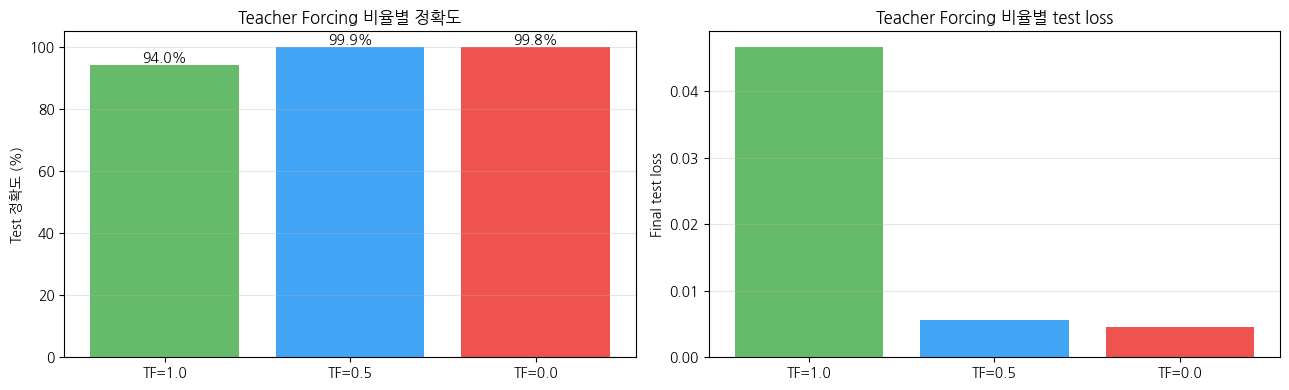


💡 인사이트:
  - TF=1.0: 학습은 빠르지만, 추론 시 자기 출력에 적응 못 해 accuracy ↓ 가능
  - TF=0.5: 균형 — 학습 안정 + 추론에도 강건
  - TF=0.0: 학습 자체가 어려움 (오류 누적)

  실무에서는 보통 TF=0.5~0.7 또는 scheduled sampling 사용!


In [15]:
# 🧪 미션 2 검증 — 시간 절약용으로 epoch 줄여서 (10 → 8)

print("=" * 60)
print("⚙️ Teacher Forcing 비율 비교 실험 (3개 모델 학습)")
print("=" * 60)

tf_results = compare_tf_ratios(ratios=[1.0, 0.5, 0.0], n_epochs=8)

# 결과 정리
print("\n\n" + "=" * 60)
print(f"{'TF ratio':<12}{'train loss':<14}{'test loss':<14}{'accuracy':<12}")
print("=" * 60)
for ratio, info in tf_results.items():
    print(f"  {ratio:<10}{info['final_train_loss']:<14.4f}"
          f"{info['final_test_loss']:<14.4f}{info['accuracy']*100:>6.1f}%")
print("=" * 60)

# 시각화
ratios_list = list(tf_results.keys())
accs = [tf_results[r]["accuracy"] * 100 for r in ratios_list]
test_losses_final = [tf_results[r]["final_test_loss"] for r in ratios_list]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar([f"TF={r}" for r in ratios_list], accs,
            color=["#66bb6a", "#42a5f5", "#ef5350"])
axes[0].set_ylabel("Test 정확도 (%)")
axes[0].set_title("Teacher Forcing 비율별 정확도")
for i, v in enumerate(accs):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar([f"TF={r}" for r in ratios_list], test_losses_final,
            color=["#66bb6a", "#42a5f5", "#ef5350"])
axes[1].set_ylabel("Final test loss")
axes[1].set_title("Teacher Forcing 비율별 test loss")
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout(); plt.show()

print("\n💡 인사이트:")
print("  - TF=1.0: 학습은 빠르지만, 추론 시 자기 출력에 적응 못 해 accuracy ↓ 가능")
print("  - TF=0.5: 균형 — 학습 안정 + 추론에도 강건")
print("  - TF=0.0: 학습 자체가 어려움 (오류 누적)")
print("\n  실무에서는 보통 TF=0.5~0.7 또는 scheduled sampling 사용!")

---
# 6️⃣ 💪 도전 과제

## 도전 1: 양방향(Bidirectional) Encoder

Encoder가 입력을 앞→뒤 + 뒤→앞 동시에 보면 더 풍부한 context를 만듭니다.

```python
self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
# 출력 hidden: (2, batch, hidden_dim) — 두 방향
# Decoder에 넘길 때는 합쳐주거나, hidden_dim을 2배로 받게 해야 함
```

## 도전 2: 더 긴 숫자 (1만~10만)

`num_to_korean`을 100,000까지 확장하고 학습 데이터를 만들어보세요.
시퀀스가 길어질수록 Context Vector 병목 문제가 심해질 거예요 — 이게 다음 노트북 Attention의 동기!

## 도전 3: 한국어 → 영어 micro-translation

```python
pairs = [
    ("나는 학생이다", "I am a student"),
    ("오늘 날씨가 좋다", "the weather is nice today"),
    ...
]
```

작은 데이터로 시도. 결과는 별로 좋지 않을 거예요 (데이터 부족) → 더 큰 데이터셋, 더 큰 모델 필요.

## 도전 4: Beam Search 추론

지금은 매 step에서 **argmax** (greedy decoding) — 한 번 틀리면 회복 불가.
**Beam Search** 는 top-k 후보를 유지하며 더 좋은 시퀀스 탐색.

```python
# 각 step에서 top 3 후보 유지, 누적 확률 곱셈으로 최종 best 선택
# 자세한 구현은 검색해보세요
```

---

# 🎓 정리

## 한 줄 요약

> **"Encoder로 입력을 압축하고, Decoder로 다른 길이의 출력 시퀀스를 생성하는 모델."**

## 오늘 만진 것들

| 무엇을 | 비유 |
|---|---|
| **Encoder** | 통역사가 듣기 (LSTM) |
| **Context vector** | 머릿속 의미 압축 |
| **Decoder** | 통역사가 말하기 (LSTM, autoregressive) |
| **SOS / EOS / PAD** | 시작/끝/패딩 특수 토큰 |
| **Teacher Forcing** | 시험 풀 때 정답 슬쩍 보여주기 |
| **Autoregressive** | 자기 출력을 다음 입력으로 |

## seq2seq의 한계 — 다음 노트북 Attention의 동기

> **Context vector 가 단 하나의 고정 길이 벡터** 라는 게 큰 병목.

```
"나는 어제 학교에서 친구를 만나고, 도서관에서 책을 읽었다." (긴 문장)
                ↓ 모두 한 벡터에 압축
        [0.23, -0.41, 0.87, ...]   ← 정보 손실 ↓
                ↓
        "I went..."  (시작은 OK)
        "I went to school yesterday and ... 그 다음 뭐였더라?"  ← 정보 잊음!
```

> **다음 노트북 Attention** 이 이 문제를 해결합니다 — "디코더가 매번 인코더의 모든 상태를 다시 보게" !

## 다음 단계 — 시리즈 흐름

| 모델 | 핵심 |
|---|---|
| RNN | 메모장 |
| LSTM | 화이트보드 + 게이트 |
| **seq2seq** (오늘) | Encoder → Decoder, 다른 길이 변환 |
| **Attention** (다음) | Context bottleneck 해결 |
| Transformer | 순차 처리 자체 제거 |

## 추천 자료

- **Cho et al. 2014** — *Learning Phrase Representations using RNN Encoder-Decoder*
- **Sutskever et al. 2014** — *Sequence to Sequence Learning with Neural Networks*
- **Andrew Ng** — *Sequence Models* 강의 (Coursera)

---

> 🎉 **수고하셨습니다!** seq2seq의 핵심 — Encoder/Decoder 분리 + Teacher Forcing — 을 직접 만들어봤습니다.
> 다음 노트북에서 Attention이 어떻게 이 한계를 풀어내는지 봐요!
